<a href="https://colab.research.google.com/github/Raghadisam2006/credit-card-fraud-detection/blob/main/CreditCardFraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
credit=pd.read_csv('/content/drive/MyDrive/datasets/creditcard.csv')

data cleaning

In [4]:
credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
credit.shape

(284807, 31)

In [8]:
credit.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
credit.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
credit.duplicated().sum()

np.int64(1081)

In [11]:
credit.drop_duplicates(inplace=True)

data visualizations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fraud count

<Axes: xlabel='Class', ylabel='count'>

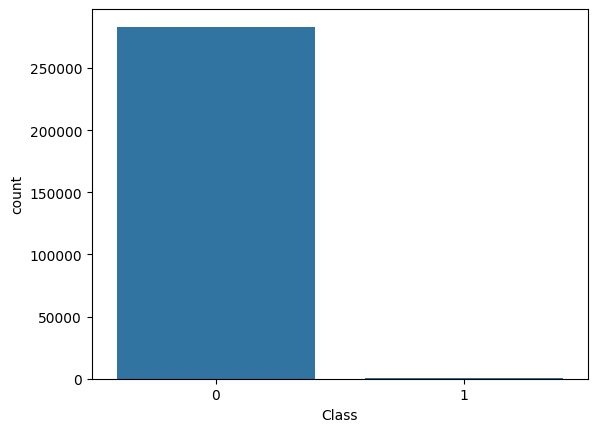

In [13]:
sns.countplot(x='Class', data=credit)

Amount Distribution

<Axes: xlabel='Amount', ylabel='Count'>

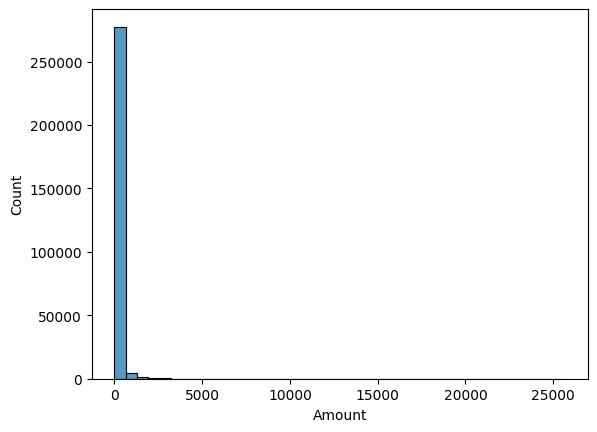

In [14]:
sns.histplot(credit["Amount"], bins=40)

Fraud vs Amount

<Axes: xlabel='Class', ylabel='Amount'>

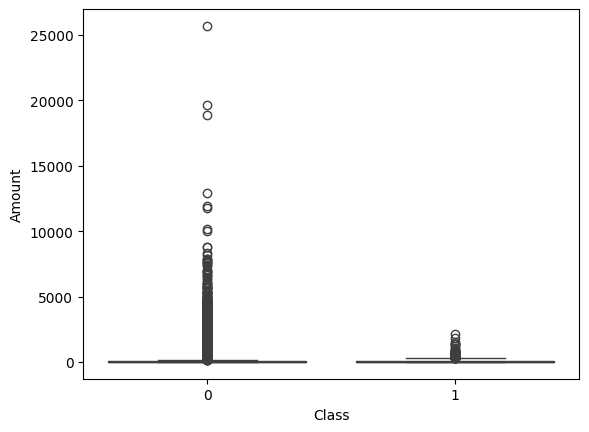

In [15]:
sns.boxplot(x="Class", y="Amount", data=credit)

Correlation Heatmap

<Axes: >

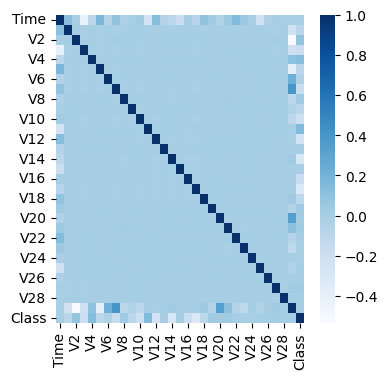

In [16]:
plt.figure(figsize=(4,4))
sns.heatmap(credit.corr(), cmap="Blues")

Pie Chart

<Axes: ylabel='count'>

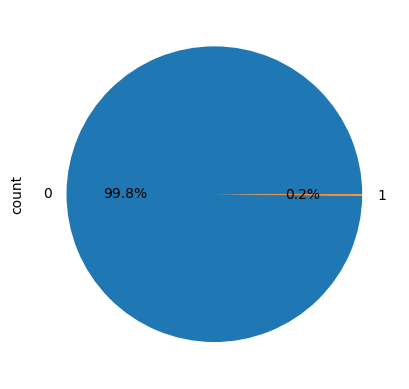

In [17]:
credit["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

Feature engineering


In [18]:
credit["LogAmount"] = np.log1p(credit["Amount"])

In [19]:
credit["Hour"] = credit["Time"] // 3600

In [20]:
X = credit.drop("Class", axis=1)

y = credit["Class"]

Feature scaling

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Train_Test split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Model training


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [26]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [29]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

DecisionTreeClassifier()

prediction

In [1]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [31]:
pred = rf.predict(X_test)

evaluation

In [32]:
accuracy_score(y_test, pred)

0.9995065731505305

In [33]:
precision_score(y_test, pred)

0.971830985915493

In [34]:
recall_score(y_test, pred)

0.7263157894736842

In [35]:
f1_score(y_test, pred)

0.8313253012048193

In [36]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



<Axes: >

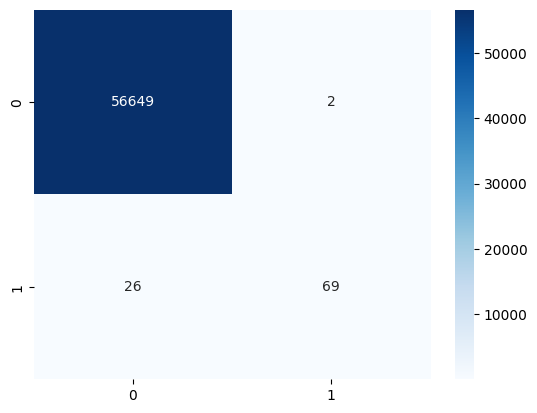

In [37]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

ROC

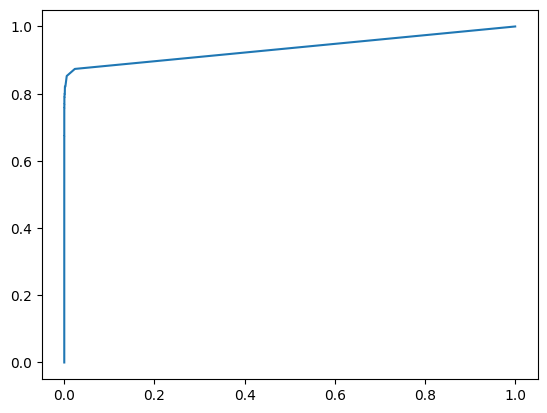

In [38]:
prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

Feature importance

predict new transactions

In [39]:
sample = X_test[0].reshape(1,-1)

rf.predict(sample)

rf.predict_proba(sample)

array([[1., 0.]])

In [56]:
# Select one unseen test transaction
sample = X_test[10].reshape(1, -1)

# Predict
prediction = rf.predict(sample)[0]

# Get probability
fraud_probability = rf.predict_proba(sample)[0][1]

if prediction == 1:
    print(" FRAUDULENT TRANSACTION")
else:
    print(" LEGITIMATE TRANSACTION")

print(f"Fraud probability: {fraud_probability:.2%}")

 LEGITIMATE TRANSACTION
Fraud probability: 0.00%


In [51]:
probability = rf.predict_proba(sample)[0]

print(probability)

[1. 0.]


In [ ]:
import joblib

joblib.dump(rf, "fraud_model.pkl")

In [ ]:
model = joblib.load("fraud_model.pkl")

In [52]:
# New Prediction
sample = X[[12]]

prediction = rf.predict(sample)

print(prediction)


[0]


In [53]:
fraud_indices = np.where(y == 1)[0]

print(fraud_indices[:10])

[ 534  616 4886 6072 6293 6295 6298 6300 6302 6388]


In [47]:
actual = y_test[10]

print("Actual class:", actual)

Actual class: 0
